Nama: Don Bosco Simorangkir

NIM: 42324035

Prodi: D3 Teknologi Informasi

Hierarchical Clustering

=== Distance Matrix (Euclidean) ===
          a         b         c         d         e         f
a  0.000000  0.707107  5.656854  3.605551  4.242641  3.201562
b  0.707107  0.000000  4.949747  2.915476  3.535534  2.500000
c  5.656854  4.949747  0.000000  2.236068  1.414214  2.500000
d  3.605551  2.915476  2.236068  0.000000  1.000000  0.500000
e  4.242641  3.535534  1.414214  1.000000  0.000000  1.118034
f  3.201562  2.500000  2.500000  0.500000  1.118034  0.000000


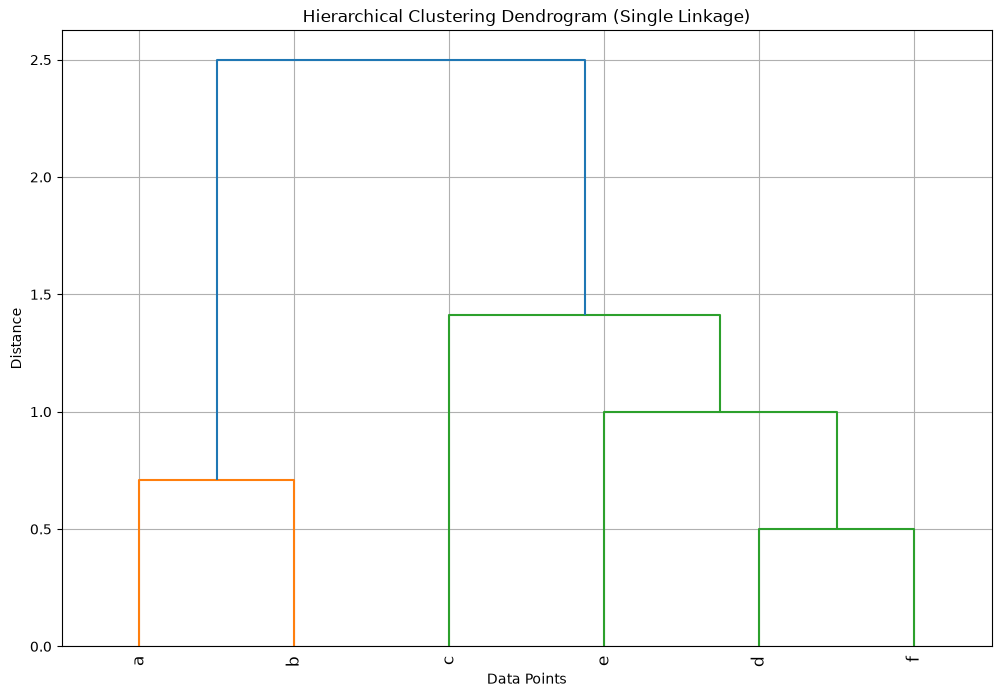

In [1]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
# 1. Dataset sederhana
data = np.array([
 [1.0, 1.0], # a
 [1.5, 1.5], # b
 [5.0, 5.0], # c
 [3.0, 4.0], # d
 [4.0, 4.0], # e
 [3.0, 3.5] # f
])
# 2. Hitung Distance Matrix (Euclidean Distance)
distance_matrix = pdist(data, metric='euclidean')
distance_df = pd.DataFrame(squareform(distance_matrix),
 columns=['a', 'b', 'c', 'd', 'e', 'f'],
 index=['a', 'b', 'c', 'd', 'e', 'f'])
# 3. Tampilkan Distance Matrix
print("=== Distance Matrix (Euclidean) ===")
print(distance_df)
# 4. Hierarchical Clustering (Single Linkage)
linked = linkage(data, method='single')
# 5. Plot Dendrogram
plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
dendrogram(linked, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

Cell pertama ini mengawali seluruh proses dengan mengimpor berbagai library penting dan menyiapkan dataset dummy berukuran kecil yang berisi enam titik koordinat untuk memudahkan pemahaman konsep dasar.

Pemuatan Pustaka: Mengimpor numpy, pandas, modul hierarki dan jarak dari scipy, serta matplotlib.pyplot untuk visualisasi.

Pembuatan Dataset: Mendefinisikan variabel data yang menampung 6 titik koordinat 2 dimensi dengan label huruf a sampai f.

Perhitungan Matriks Jarak: Menghitung jarak antar titik menggunakan metode Euclidean Distance melalui fungsi pdist dan squareform.

Menampilkan Matriks: Mencetak tabel Distance Matrix menggunakan pandas DataFrame agar hubungan kedekatan antar titik terlihat secara nyata.

Klasterisasi & Plotting: Menjalankan fungsi linkage dengan parameter single linkage dan memvisualisasikannya ke dalam bentuk grafik dendrogram.

In [1]:
import pandas as pd
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Memasuki eksperimen kedua yang menggunakan data dunia nyata, cell ini bertugas untuk membaca file data pelanggan dari penyimpanan sistem.   
1. Membaca File CSV: Menggunakan fungsi pd.read_csv() untuk memuat dataset Mall_Customers.csv ke dalam variabel df.   
2. Pemeriksaan Data Awal: Menjalankan perintah df.head() untuk menampilkan lima baris data teratas.   
3. Identifikasi Kolom: Memeriksa kolom yang tersedia seperti CustomerID, Genre, Age, Annual Income (k$), dan Spending Score (1-100).

In [2]:
x = df.iloc[:, [3, 4]].values

Pada cell ini, kita melakukan penyaringan untuk mengambil kolom spesifik yang akan menjadi acuan utama dalam proses pengelompokan pelanggan.   
1. Ekstraksi Kolom: Menggunakan fungsi indeks df.iloc[:, [3, 4]] untuk mengambil kolom ke-3 dan ke-4 saja.   
2. Fokus Fitur: Kolom yang dipilih adalah pendapatan tahunan (Annual Income) dan skor pengeluaran (Spending Score).   
3. Konversi Array: Mengubah data terpilih menjadi bentuk nilai murni menggunakan .values dan menyimpannya ke dalam variabel x. 

In [3]:
from sklearn.preprocessing import StandardScaler
data_scaler = StandardScaler()
scaled_data = data_scaler.fit_transform(x)
scaled_data.shape

(200, 2)

Cell keempat ini melakukan standarisasi data agar rentang nilai fitur memiliki skala yang setara sebelum dihitung jaraknya.   
1. Inisialisasi Scaler: Mengimpor dan menyiapkan objek StandardScaler dari pustaka scikit-learn.   
2. Transformasi Data: Menerapkan fungsi fit_transform(x) untuk menormalkan data fitur agar memiliki rata-rata nol dan deviasi standar satu.   
3. Validasi Ukuran: Mengecek dimensi data melalui scaled_data.shape yang menghasilkan output (200, 2) untuk memastikan data berisi 200 baris pelanggan dengan 2 kolom fitur.

In [4]:
from scipy.cluster.hierarchy import linkage, dendrogram
clustering = linkage(scaled_data, method="complete", metric="euclidean")

Cell kelima menjalankan inti dari algoritma klasterisasi hierarki lanjutan dengan menerapkan metode penggabungan yang berbeda dari eksperimen pertama.   
1. Impor Modul Hierarki: Memanggil fungsi linkage dan dendrogram dari modul scipy.cluster.hierarchy.   
2. Metode Complete Linkage: Menjalankan fungsi linkage dengan parameter method="complete" dan metric="euclidean" pada data yang sudah diskalakan (scaled_data).   
3. Penyimpanan Model: Menyimpan hasil perhitungan hierarki ke dalam variabel clustering. 

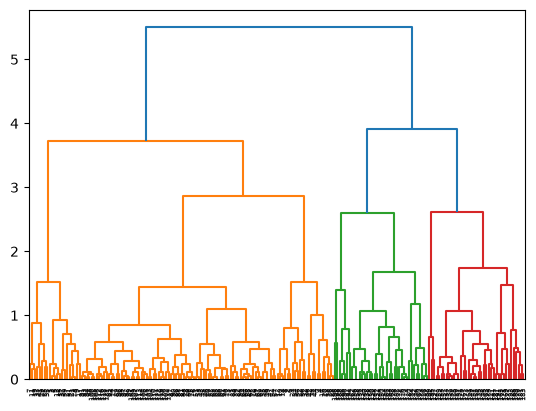

In [5]:
import matplotlib.pyplot as plt
dendrogram(clustering)
plt.show()

Cell terakhir berfungsi untuk menampilkan hasil visualisasi akhir berupa diagram pohon yang komprehensif dari ratusan data pelanggan mall.   
1. Pangaturan Plot: Mengimpor matplotlib.pyplot untuk memetakan grafik.   
2. Fungsi Dendrogram: Memanggil dendrogram(clustering) untuk merender diagram pohon hierarki berdasarkan model yang telah diproses.   
3. Visualisasi Akhir: Menggunakan plt.show() untuk menampilkan grafik yang membagi pelanggan ke dalam kelompok warna berbeda (seperti oranye, hijau, dan merah) guna membantu keperluan segmentasi strategi bisnis.

=========================================================================================================================


Tugas!!
Pada percobaan pertama dengan dataset sederhana, bandingkan hasil plot dendrogram single linkage dengan complete linkage
dan average linkage

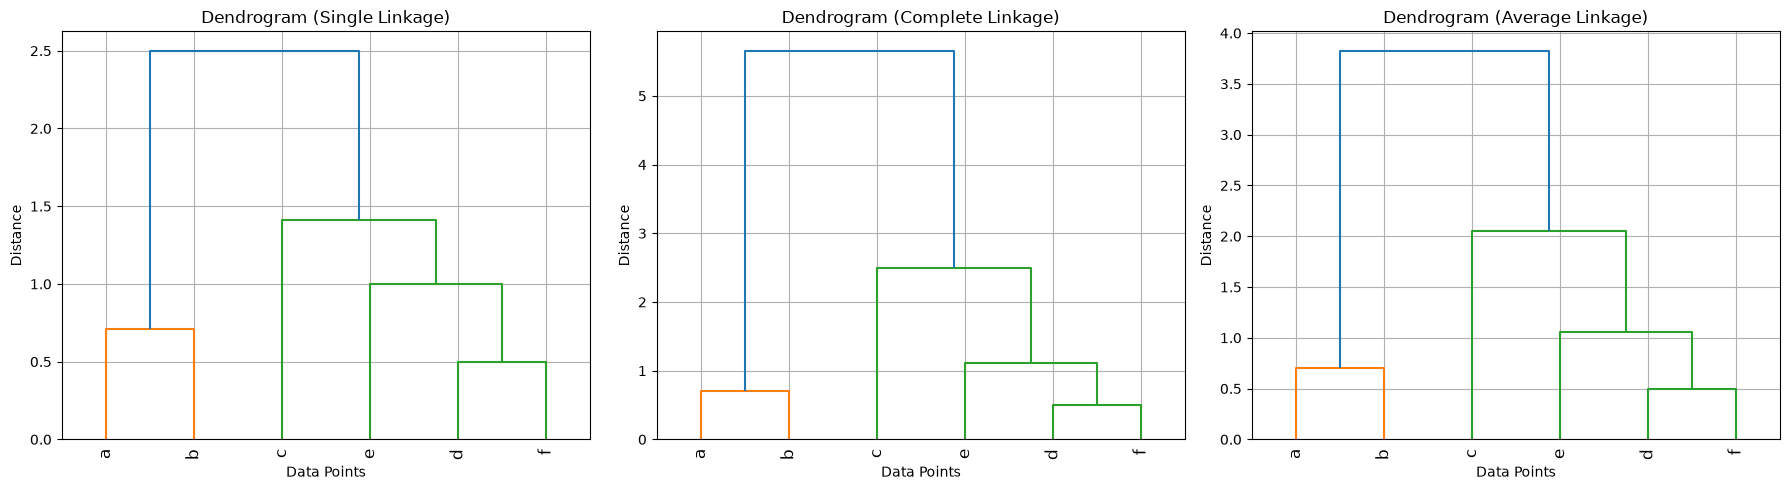

In [6]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

# 1. Dataset sederhana (sama seperti percobaan pertama)
data = np.array([
    [1.0, 1.0],  # a
    [1.5, 1.5],  # b
    [5.0, 5.0],  # c
    [3.0, 4.0],  # d
    [4.0, 4.0],  # e
    [3.0, 3.5]   # f
])

# 2. Membuat 3 subplots untuk membandingkan ketiga metode linkage
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods = ['single', 'complete', 'average']
titles = ['Single Linkage', 'Complete Linkage', 'Average Linkage']

for ax, method, title in zip(axes, methods, titles):
    # Melakukan hierarchical clustering berdasarkan method yang dipilih
    linked = linkage(data, method=method)
    
    # Membuat dendrogram pada masing-masing axis
    dendrogram(linked, labels=['a', 'b', 'c', 'd', 'e', 'f'], ax=ax, leaf_rotation=90)
    ax.set_title(f"Dendrogram ({title})")
    ax.set_xlabel("Data Points")
    ax.set_ylabel("Distance")
    ax.grid(True)

plt.tight_layout()
plt.show()

a. Single Linkage (Minimum Distance):

Cara Kerja: Mengukur jarak antar dua klaster berdasarkan jarak terpendek dari pasangan titik di dalam klaster tersebut.

Karakteristik Hasil: Cenderung menghasilkan efek rantai (chaining effect), di mana klaster dapat memanjang karena titik-titik digabungkan berdasarkan tetangga terdekatnya saja.

b. Complete Linkage (Maximum Distance):

Cara Kerja: Mengukur jarak antar dua klaster berdasarkan jarak terjauh dari pasangan titik di antara kedua klaster tersebut.

Karakteristik Hasil: Cenderung menghasilkan klaster yang lebih padat dan kompak, karena penggabungan antar klaster baru akan terjadi jika jarak maksimum antar anggotanya sudah cukup dekat.

c. Average Linkage:

Cara Kerja: Mengukur jarak antar dua klaster dengan menghitung rata-rata jarak keseluruhan pasangan titik yang ada di antara kedua klaster tersebut.

Karakteristik Hasil: Memberikan hasil yang berada di tengah-tengah (moderat) antara single dan complete linkage, serta tidak terlalu rentan terhadap efek rantai maupun pencilan (outliers).